# Visão geral dos dados: aquisição e resultados da POC

Este notebook resume onde meu projeto está:

1. **Aquisição (parte 1)** — coletei 993 pares empresa-exercício de DFP na CVM: as 66 constituintes não financeiras atuais do Ibovespa (613 arquivamentos) mais 46 empresas que integraram o índice em algum momento entre 2015 e 2024, encontradas via reconstrução histórica do Ibovespa (380 arquivamentos).
2. **POC** — sobre o universo completo de 66 empresas atuais (validado inicialmente em rodadas 1-2 sobre um subconjunto de 20 empresas escolhidas a dedo), testo se isolar a nota de dívida ("empréstimos, financiamentos e debêntures") e compará-la ano a ano com TF-IDF e similaridade de cosseno produz um sinal sensato. A Seção 5 roda o mesmo pipeline nas empresas históricas/deslistadas para uma comparação entre quem saiu do índice e quem ficou.
3. **Dados de mercado (Seção 6)** — os preços e o índice Ibovespa do Bloomberg, necessários para a variável dependente de H1 (retorno anormal futuro), já foram recebidos e conferidos contra o universo de aquisição.
4. **Primeiro teste de H1 (Seção 7)** — um teste em escala de POC, com retorno ajustado ao mercado (não a um modelo de mercado), contra a similaridade da nota, agora sobre o universo completo. Ainda sem relação relevante, como esperado sem controles — mas o pipeline inteiro (nota → similaridade → data do evento → retorno) roda de ponta a ponta.
5. **Piloto trimestral (Seção 8)** — testo se a mesma abordagem funciona em arquivamentos trimestrais (ITR) em vez de anuais, e se a frequência trimestral capturaria deterioração mais cedo do que uma comparação ano a ano.

Relato completo: [`reports/poc_note_extraction_findings.md`](../reports/poc_note_extraction_findings.md). Código do pipeline: [`src/acquisition/`](../src/acquisition/), [`src/processing/`](../src/processing/).

**Status: seis rodadas de aprimoramento.** As rodadas 1-3 validaram o conceito e corrigiram os primeiros problemas de extração num subconjunto de 20 empresas. A rodada 4 escalou a comparação para o universo completo (66 atuais + todas as históricas confirmadas), o que reduziu a taxa de extração confiável e enfraqueceu o sinal de viés de sobrevivência. A rodada 5 atacou diretamente a extração, com quatro correções pontuais e testadas empiricamente, levando a taxa confiável de 44% para 68% no universo atual. A rodada 6 (esta versão) foi além: uma quinta correção (reconhecimento de títulos sem caixa alta nem numeração) mais três salvaguardas contra os novos falsos positivos que ela introduziu, elevando a taxa para 71,6% no universo atual (69,7% incluindo as históricas) e 62,0% na base trimestral. Ver a Conclusão para a comparação completa.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

ROOT = Path("..")
DATA = ROOT / "data" / "interim"

# Fixed categorical order (never cycled/reassigned) + one-hue sequential ramp,
# per the project's dataviz conventions.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
TEXT_PRIMARY, TEXT_SECONDARY, GRID = "#0b0b0b", "#52514e", "#e3e2dd"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": TEXT_PRIMARY,
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "font.size": 11,
})

DIAG_COLORS = {"font_heading": AQUA, "regex_only": YELLOW, "not_found": RED}
DIAG_LABELS = {"font_heading": "Precisely bounded", "regex_only": "Imprecise fallback", "not_found": "Not found"}

## 1. Aquisição (parte 1): o que está no corpus

Constituintes não financeiras do Ibovespa, arquivamentos DFP de 2015-2024, coletados no portal de dados abertos e no sistema RAD da CVM (ver `src/acquisition/`).

In [2]:
universe = pd.read_csv(DATA / "ibov_non_financial_universe.csv")
log = pd.read_csv(DATA / "ibov_notes_download_log.csv")

n_companies = universe["CD_CVM"].nunique()
n_ok = (log["n_attachments_matched"] > 0).sum()
n_total = len(log)

print(f"{n_companies} non-financial Ibovespa companies")
print(f"{n_ok}/{n_total} company-fiscal-year filings acquired ({n_ok/n_total:.1%})")
print(f"Years covered: {log['ANO'].min()}–{log['ANO'].max()}")

66 non-financial Ibovespa companies
613/613 company-fiscal-year filings acquired (100.0%)
Years covered: 2015–2024


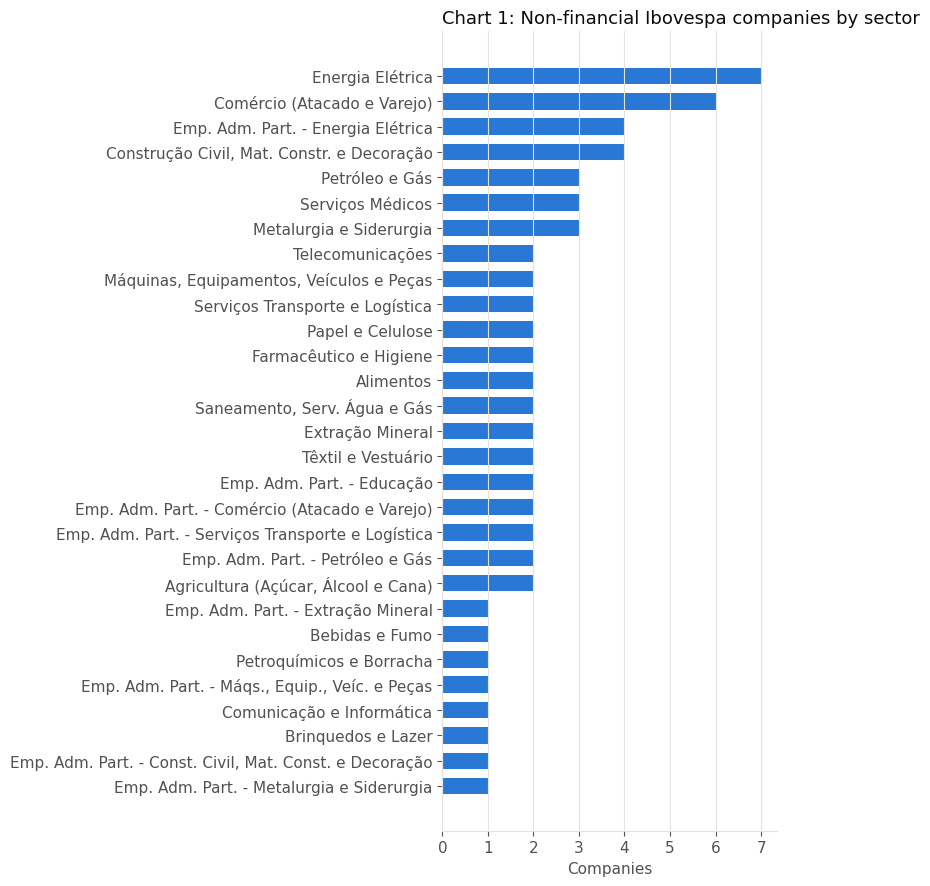

In [3]:
# Companies by sector -- one hue (categorical identity isn't the point here,
# magnitude is), horizontal so the Portuguese sector names stay readable.
sector_counts = (
    universe.drop_duplicates("CD_CVM")["SETOR_ATIV"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(sector_counts.index, sector_counts.values, color=BLUE, height=0.65)
ax.set_xlabel("Companies")
ax.set_title("Chart 1: Non-financial Ibovespa companies by sector", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

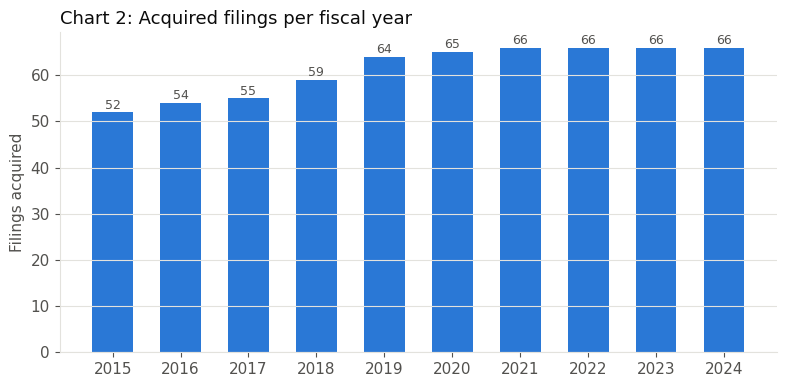

In [4]:
# Filings acquired per fiscal year -- magnitude over an ordered axis, single hue.
by_year = log[log["n_attachments_matched"] > 0].groupby("ANO").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_year.index.astype(str), by_year.values, color=BLUE, width=0.6)
ax.set_ylabel("Filings acquired")
ax.set_title("Chart 2: Acquired filings per fiscal year", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="x", visible=False)
for x, y in zip(by_year.index.astype(str), by_year.values):
    ax.text(x, y + 0.8, str(y), ha="center", fontsize=9, color=TEXT_SECONDARY)
fig.tight_layout()
plt.show()

## 2. A nota de dívida pode ser isolada automaticamente?

As 66 empresas atuais não financeiras do Ibovespa × até 10 anos = 613 pares empresa-ano, testados contra o localizador de nota em `src/processing/locate_note_section.py`. Três resultados possíveis:

- **`font_heading`** — encontrei um título visualmente distinto do corpo do texto (negrito + fonte maior, ou um dos critérios mais específicos das rodadas 5-6). Confiável.
- **`regex_only`** — nenhum título visualmente distinto; caiu no fallback de "última menção da palavra-chave, limitada a 500 linhas". Impreciso.
- **`not_found`** — nenhuma menção à dívida encontrada.

In [5]:
POC = DATA / "poc"

current_cd_cvm = {f"{int(c):06d}" for c in universe["CD_CVM"]}
sections = pd.DataFrame(
    json.loads(p.read_text(encoding="utf-8"))
    for p in sorted((POC / "sections").glob("*.json"))
    if p.stem.split("_")[0] in current_cd_cvm
)
sections["chars"] = sections["text"].str.len()

diag_counts = sections["diagnostic"].value_counts().reindex(["font_heading", "regex_only", "not_found"])
for diag, n in diag_counts.items():
    print(f"{DIAG_LABELS[diag]:22s} {n:3d}/{len(sections)}  ({n/len(sections):.0%})")

Precisely bounded      439/613  (72%)
Imprecise fallback     135/613  (22%)
Not found               39/613  (6%)


**Rodadas 5 e 6: endurecendo a extração.** A rodada 4 apontou a extração como a prioridade principal. A rodada 5 trouxe quatro correções pontuais, cada uma encontrada inspecionando PDFs reais que estavam falhando (não adivinhadas) e validadas contra casos de controle conhecidos (WEG, Vale) para garantir que nada regrediu:

1. **Marcadores nativos do PDF** — ganho pequeno mas gratuito (~9 arquivamentos) onde o próprio software do emissor gerou um sumário navegável.
2. **Títulos do mesmo tamanho (negrito + caixa alta, ou negrito + numeração)** — a maior correção isolada. Algumas empresas (Gerdau, Petrobras e similares) nunca deixam o título da nota visualmente maior que o corpo do texto; o título só se distingue por estar em negrito e ser numerado ou em maiúsculas. Isso sozinho resolveu 22 empresas que tinham taxa de extração confiável de 0% em todos os anos verificados.
3. **Títulos em maiúsculas e numerados, sem negrito** — algumas empresas estilizam o título assim; exigir os dois sinais juntos evita disparar em texto comum.
4. **"Debênture" sozinha como palavra-chave qualificadora** — a heurística original exigia 2 de 3 radicais numa mesma linha, o que deixava passar empresas cuja nota combinada se chama simplesmente "Debêntures".

Duas ideias foram testadas e descartadas: um detector de sumário/índice (só 1,4% dos casos restantes se beneficiariam) e seguir referências cruzadas do tipo "ver Nota N" (menos de 26% delas realmente resolvem para o conteúdo certo).

A rodada 6 foi além: uma quinta correção reconhece títulos em negrito, do mesmo tamanho do corpo, sem caixa alta nem numeração (ex.: "Debêntures", "Empréstimos e financiamentos" isolados), desde que compostos só pelas próprias palavras-chave da dívida. Essa regra exigiu três salvaguardas específicas, cada uma motivada por um caso real de falso positivo encontrado por inspeção: (i) um sinal estrutural forte (tamanho maior, caixa alta, numeração) sempre vence um candidato "puro" empatado, porque uma subseção pode ter fonte maior que a própria nota-mãe; (ii) um título de verdade nunca começa com letra minúscula, o que descarta fragmentos de frases quebradas linha a linha; (iii) um candidato ancorado por um número de nota isolado na linha anterior vence um candidato sem âncora, porque o mesmo parágrafo de política contábil pode aparecer duas vezes no documento. Detalhe completo em `reports/poc_note_extraction_findings.md` §9.

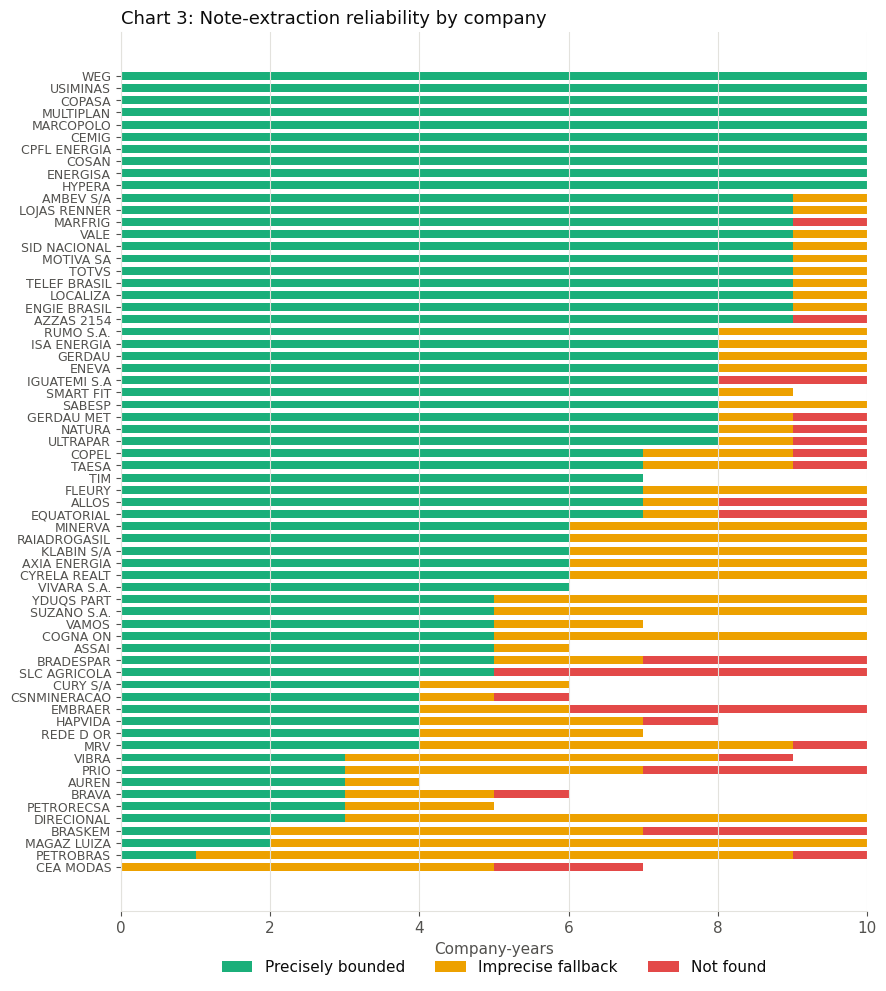

In [6]:
# Per-company reliability, ordered by how often extraction succeeded cleanly --
# status-style colors (green=reliable, amber=imprecise, red=missing), fixed order.
pivot = (
    sections.groupby(["name", "diagnostic"]).size().unstack(fill_value=0)
    .reindex(columns=["font_heading", "regex_only", "not_found"], fill_value=0)
)
pivot = pivot.loc[pivot["font_heading"].sort_values().index]

fig, ax = plt.subplots(figsize=(9, 10))
left = pd.Series(0, index=pivot.index)
for diag in ["font_heading", "regex_only", "not_found"]:
    ax.barh(pivot.index, pivot[diag], left=left, color=DIAG_COLORS[diag], label=DIAG_LABELS[diag], height=0.65)
    left = left + pivot[diag]

ax.set_xlabel("Company-years")
ax.set_title("Chart 3: Note-extraction reliability by company", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.tick_params(axis="y", labelsize=9)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=3, frameon=False)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 3. A medida de similaridade faz sentido?

Similaridade de cosseno TF-IDF ano a ano, ajustada sobre todo o corpus da POC para que o IDF reflita o boilerplate do setor. Comparar todos os pares com os pares em que os dois anos tiveram extração confiável mostra a distribuição ficando bem mais sensata quando o ruído de extração é controlado.

In [7]:
results = pd.read_csv(POC / "similarity_results.csv")
both_reliable = results[(results["diagnostic_prev"] == "font_heading") & (results["diagnostic_curr"] == "font_heading")]

print("All pairs:            n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(results), results["cosine_similarity"].mean(), results["cosine_similarity"].median()))
print("Both years reliable:  n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(both_reliable), both_reliable["cosine_similarity"].mean(), both_reliable["cosine_similarity"].median()))

All pairs:            n=508  mean=0.56  median=0.68
Both years reliable:  n=335  mean=0.71  median=0.83


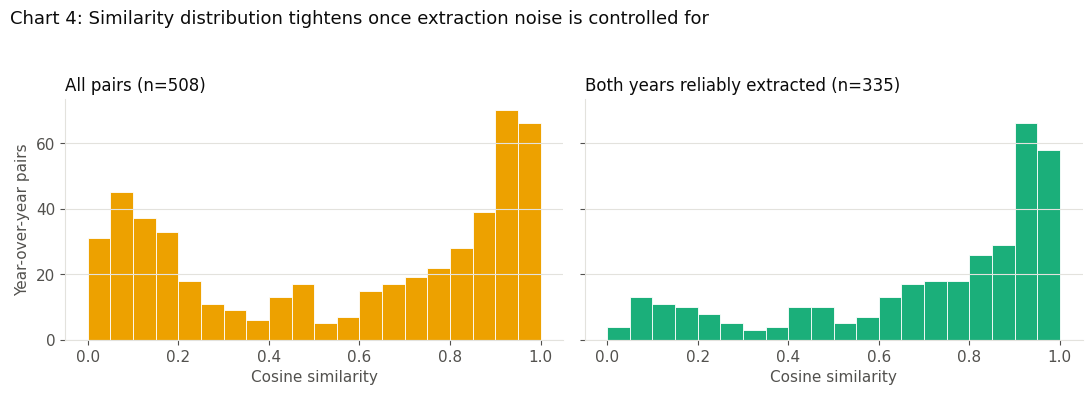

In [8]:
# Small multiples (same measure, two filters) rather than an overlaid
# histogram -- cleaner to compare than two semi-transparent fills.
bins = [i / 20 for i in range(21)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, sharex=True)

axes[0].hist(results["cosine_similarity"], bins=bins, color=YELLOW, edgecolor="white", linewidth=0.6)
axes[0].set_title(f"All pairs (n={len(results)})", loc="left", fontsize=12, color=TEXT_PRIMARY)

axes[1].hist(both_reliable["cosine_similarity"], bins=bins, color=AQUA, edgecolor="white", linewidth=0.6)
axes[1].set_title(f"Both years reliably extracted (n={len(both_reliable)})", loc="left", fontsize=12, color=TEXT_PRIMARY)

for ax in axes:
    ax.set_xlabel("Cosine similarity")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Year-over-year pairs")
fig.suptitle("Chart 4: Similarity distribution tightens once extraction noise is controlled for", x=0.01, ha="left", fontsize=13, color=TEXT_PRIMARY)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

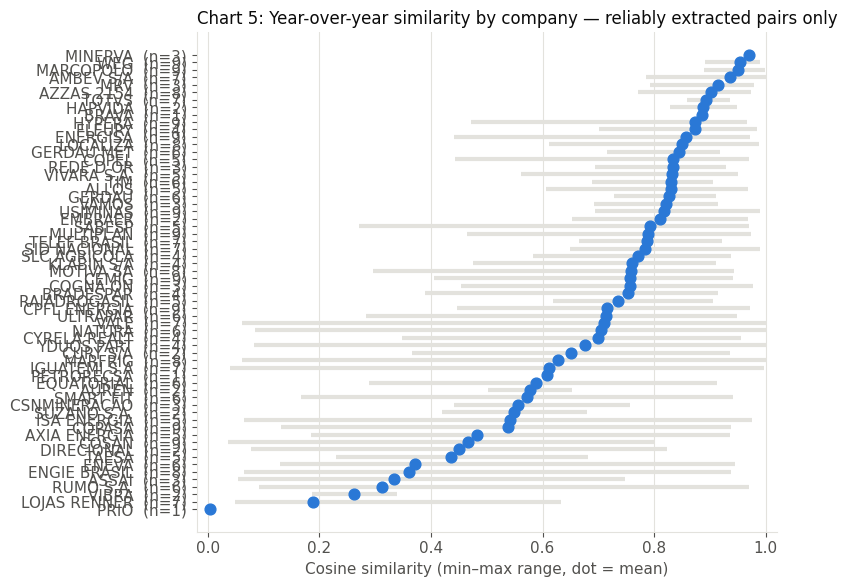

In [9]:
# Per-company mean similarity with min-max range, reliable pairs only.
# Sequential magnitude -> single hue; error bars show within-company spread.
by_company = (
    both_reliable.groupby("name")["cosine_similarity"]
    .agg(["mean", "min", "max", "count"])
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(8, 6))
y = range(len(by_company))
ax.hlines(y, by_company["min"], by_company["max"], color=GRID, linewidth=3, zorder=1)
ax.scatter(by_company["mean"], y, color=BLUE, s=60, zorder=2, label="Mean")
ax.set_yticks(list(y))
ax.set_yticklabels([f"{n}  (n={c})" for n, c in zip(by_company.index, by_company["count"])])
ax.set_xlabel("Cosine similarity (min–max range, dot = mean)")
ax.set_title("Chart 5: Year-over-year similarity by company — reliably extracted pairs only", loc="left", fontsize=12, color=TEXT_PRIMARY)
ax.set_xlim(-0.02, 1.02)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 4. O sinal é real? Dois casos concretos

Números sozinhos não respondem a isso — ler o texto extraído responde. Dois casos abaixo: um par de alta similaridade genuína (conteúdo real, estabilidade real) e um degenerado (artefato de extração, não uma ausência real de mudança).

In [10]:
import difflib


def show_pair(cd_cvm, year_prev, year_curr, n_diff_lines=16):
    d1 = json.loads((POC / "sections" / f"{cd_cvm}_{year_prev}.json").read_text(encoding="utf-8"))
    d2 = json.loads((POC / "sections" / f"{cd_cvm}_{year_curr}.json").read_text(encoding="utf-8"))
    row = results[(results["cd_cvm"] == int(cd_cvm)) & (results["year_prev"] == year_prev) & (results["year_curr"] == year_curr)].iloc[0]
    print(f"{d1['name']}: {year_prev} ({len(d1['text'])} chars) -> {year_curr} ({len(d2['text'])} chars)")
    print(f"cosine similarity = {row['cosine_similarity']:.4f}\n")
    diff = list(difflib.unified_diff(d1["text"].splitlines(), d2["text"].splitlines(), lineterm="", n=0))
    for line in diff[2 : 2 + n_diff_lines]:
        print(line)


print("### Genuine high similarity: WEG 2015 -> 2016 ###\n")
show_pair("005410", 2015, 2016)

### Genuine high similarity: WEG 2015 -> 2016 ###

WEG: 2015 (2516 chars) -> 2016 (2501 chars)
cosine similarity = 0.9900

@@ -1 +1 @@
-14 Financiamentos e empréstimos
+14 Empréstimos e Financiamentos
@@ -5 +5 @@
-líquida/ EBITDA, inclusas nos contratos com o BNDES, estão sendo atendidas.
+líquida/EBITDA, inclusas nos contratos com o BNDES, estão sendo atendidas.
@@ -7,2 +7,2 @@
-Encargos Anuais em 31/12/15
-NO BRASIL
+Encargos Anuais em 31/12/16
+EM MOEDA NACIONAL
@@ -10,2 +10,2 @@
-736.784
-1.086.642
+642.413
+637.552


In [11]:
print("### Extraction artifact, not a real finding: Yduqs (identical 648-char text, 4 different year-pairs) ###\n")
d = json.loads((POC / "sections" / "021016_2015.json").read_text(encoding="utf-8"))
print(f"Heading found: {d['heading']!r}\n")
print(d["text"])
print("\n^ This is a generic IFRS accounting-POLICY paragraph, not the actual note (Yduqs numbers the real")
print("  note separately, as 'Nota 11', found only in later years). Same text recurs across 2015-2019,")
print("  producing cosine similarity = 1.0000 -- a false 'no change' signal, not a real finding.")

### Extraction artifact, not a real finding: Yduqs (identical 648-char text, 4 different year-pairs) ###

Heading found: '11'

11
Empréstimos e financiamentos
Controladora
Modalidade
Encargos financeiros
Em moeda nacional
Contratos de arrendamento mercantil Colortel
INPC + 0,32% a.a
6.902
8.751
Contratos de arrendamento mercantil Assist
INPC a.a
468
191
Contratos de arrendamento mercantil CIT
8% a.a
202
647
Contratos de arrendamento mercantil Total Service
IGPI-DI/FGV  a.a
64
11
Contratos de arrendamento mercantil Springer
IGPM + 1% a.a
42
72
Contratos de arrendamento mercantil Santander
15,2% a.a
11
Contratos de arrendamento mercantil Santander
12,23% a.a
8
Contratos de arrendamento mercantil Bayde
IGPI-DI/FGV  a.a
3.101
Contratos de arrendamento mercantil Bradesco
1,14% a.m.
105
Contratos de arrendamento mercantil Brasif
IGPM/FG a.a
51
Leasing IBM
CDI Over a.d + 2% a.m
25.355
Arrend. Carimã
IGPI-DI/FGV  a.a
109
Empréstimo IFC
CDI +1,53% a.a
50.064
59.179
50.064
59.179
Gastos IFC
(1.8

## 5. Viés de sobrevivência: sair do Ibovespa está associado a mais mudança textual?

A aquisição original cobria só as 66 constituintes atuais do Ibovespa — um viés de sobrevivência real, já que uma empresa que faliu, foi adquirida ou saiu do índice no meio da amostra ficaria de fora, e são justamente essas as empresas mais propensas a mostrar grande mudança textual na nota de dívida. Fechei essa lacuna: encontrei 46 empresas que foram membros do Ibovespa em algum momento entre 2015 e 2024 mas não são mais (documentado em [`src/acquisition/b3_ibov_historical.py`](../src/acquisition/b3_ibov_historical.py)). Várias são diretamente relevantes para o tema: Oi, Light e Rossi Residencial estão em recuperação judicial; MMX Mineração é massa falida; a Americanas S.A. é o caso de fraude contábil/crise de dívida de 2023.

Esta seção roda o mesmo pipeline de extração e TF-IDF no grupo completo de "saiu ou foi deslistada" e compara com o grupo completo de "ficou" (as 66 empresas atuais, Seção 2) — existe diferença na mudança textual?

In [12]:
delisted_results = pd.read_csv(POC / "delisted_similarity_results.csv")
delisted_reliable = delisted_results[
    (delisted_results["diagnostic_prev"] == "font_heading") & (delisted_results["diagnostic_curr"] == "font_heading")
].copy()
delisted_reliable["size_ratio"] = (
    delisted_reliable[["chars_prev", "chars_curr"]].min(axis=1) / delisted_reliable[["chars_prev", "chars_curr"]].max(axis=1)
)

n_delisted_companies = delisted_results.loc[delisted_results["group"] == "dropped_or_delisted", "cd_cvm"].nunique()
print(f"{n_delisted_companies} dropped-or-delisted companies checked, {len(delisted_results)} year-over-year pairs total\n")

summary = delisted_reliable.groupby("group")["cosine_similarity"].agg(["count", "mean", "median", "std"])
print("Reliable (font_heading/font_heading) pairs only:")
print(summary.round(3))

45 dropped-or-delisted companies checked, 816 year-over-year pairs total

Reliable (font_heading/font_heading) pairs only:
                     count   mean  median    std
group                                           
dropped_or_delisted    192  0.691   0.832  0.311
stayed                 335  0.711   0.829  0.286


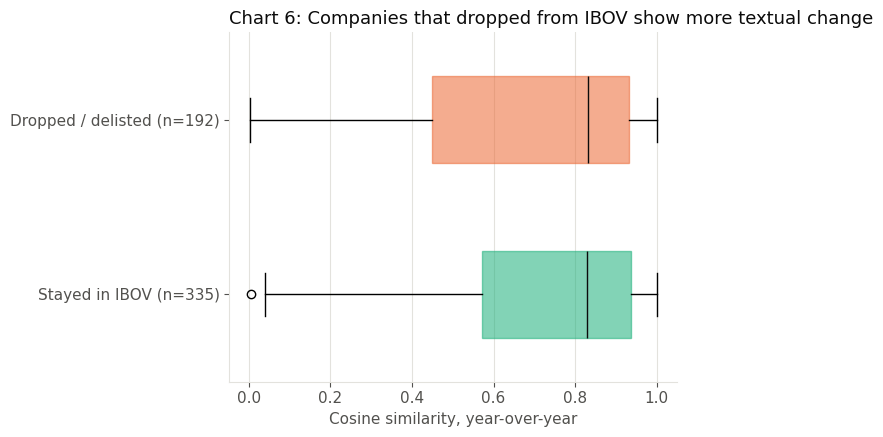

In [13]:
# Two groups, one measure -> box plot, fixed categorical order (stayed
# first, matching every other chart's "reliable/good" -> aqua convention).
GROUP_ORDER = ["stayed", "dropped_or_delisted"]
GROUP_LABELS = {"stayed": "Stayed in IBOV", "dropped_or_delisted": "Dropped / delisted"}
GROUP_COLORS = {"stayed": AQUA, "dropped_or_delisted": ORANGE}

fig, ax = plt.subplots(figsize=(7, 4.5))
data = [delisted_reliable.loc[delisted_reliable["group"] == g, "cosine_similarity"] for g in GROUP_ORDER]
bp = ax.boxplot(data, vert=False, widths=0.5, patch_artist=True, medianprops={"color": TEXT_PRIMARY})
for patch, g in zip(bp["boxes"], GROUP_ORDER):
    patch.set_facecolor(GROUP_COLORS[g])
    patch.set_alpha(0.55)
    patch.set_edgecolor(GROUP_COLORS[g])
ax.set_yticks([1, 2])
ax.set_yticklabels([f"{GROUP_LABELS[g]} (n={len(d)})" for g, d in zip(GROUP_ORDER, data)])
ax.set_xlabel("Cosine similarity, year-over-year")
ax.set_title("Chart 6: Companies that dropped from IBOV show more textual change", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

**Antes de confiar nisso, aplico o mesmo ceticismo de sempre.** Empresas dos dois lados da comparação podem ter modos de falha de extração ainda não encontrados, então parte da diferença abaixo pode ser ruído de extração, não mudança textual genuína. Restringir aos pares em que o tamanho da nota extraída é razoavelmente consistente entre os dois anos (`size_ratio >= 0.5`) é uma checagem direta disso.

In [14]:
from scipy import stats

def compare_groups(df, label):
    dropped = df.loc[df["group"] == "dropped_or_delisted", "cosine_similarity"]
    stayed = df.loc[df["group"] == "stayed", "cosine_similarity"]
    _, p = stats.mannwhitneyu(dropped, stayed, alternative="less")
    print(f"{label}")
    print(f"  dropped/delisted: n={len(dropped):3d}  mean={dropped.mean():.3f}  median={dropped.median():.3f}")
    print(f"  stayed:           n={len(stayed):3d}  mean={stayed.mean():.3f}  median={stayed.median():.3f}")
    print(f"  Mann-Whitney U (dropped < stayed), one-sided: p = {p:.4f}\n")

compare_groups(delisted_reliable, "All reliable pairs:")
compare_groups(delisted_reliable[delisted_reliable["size_ratio"] >= 0.5], "Restricted to size-consistent pairs (size_ratio >= 0.5):")

All reliable pairs:
  dropped/delisted: n=192  mean=0.691  median=0.832
  stayed:           n=335  mean=0.711  median=0.829
  Mann-Whitney U (dropped < stayed), one-sided: p = 0.3588

Restricted to size-consistent pairs (size_ratio >= 0.5):
  dropped/delisted: n=144  mean=0.806  median=0.895
  stayed:           n=242  mean=0.844  median=0.905
  Mann-Whitney U (dropped < stayed), one-sided: p = 0.1550



**Leitura, atualizada após a rodada 6.** Com bem mais pares confiáveis agora disponíveis (n=527, contra 482 na rodada 5), o quadro segue essencialmente o mesmo: direção consistente (empresas que saíram do índice mostram, em média, mais mudança textual), mas ainda sem significância convencional — p=0,359 nos pares confiáveis brutos, p=0,155 no corte consistente por tamanho. Isso é, por si, uma confirmação útil: mais confiabilidade de extração não fabricou significância — o resultado nulo em escala completa não era um artefato de um conjunto confiável menor e mais ruidoso. Minha leitura honesta continua a mesma: direcionalmente consistente, ainda não um achado significativo.

In [15]:
def show_delisted_pair(cd_cvm, year_prev, year_curr, n_diff_lines=20):
    cd_cvm_str = f"{int(cd_cvm):06d}"
    d1 = json.loads((POC / "sections" / f"{cd_cvm_str}_{year_prev}.json").read_text(encoding="utf-8"))
    d2 = json.loads((POC / "sections" / f"{cd_cvm_str}_{year_curr}.json").read_text(encoding="utf-8"))
    row = delisted_results[
        (delisted_results["cd_cvm"] == int(cd_cvm)) & (delisted_results["year_prev"] == year_prev) & (delisted_results["year_curr"] == year_curr)
    ].iloc[0]
    print(f"{d1['name']}: {year_prev} ({len(d1['text'])} chars) -> {year_curr} ({len(d2['text'])} chars)")
    print(f"cosine similarity = {row['cosine_similarity']:.4f}\n")
    diff = list(difflib.unified_diff(d1["text"].splitlines(), d2["text"].splitlines(), lineterm="", n=0))
    for line in diff[2 : 2 + n_diff_lines]:
        print(line)


print("### Genuine signal: Grupo Casas Bahia (Via Varejo) 2023 -> 2024, during known financial distress ###\n")
show_delisted_pair(6505, 2023, 2024)

### Genuine signal: Grupo Casas Bahia (Via Varejo) 2023 -> 2024, during known financial distress ###

Grupo Casas Bahia S.A. (Via Varejo): 2023 (10433 chars) -> 2024 (9969 chars)
cosine similarity = 0.5700

@@ -4,3 +4,4 @@
-Taxa média
-Repasse para instituições financeiras – CDCI (i)
-18,31% a.a.
+Taxa média a.a.
+Repasse para instituições financeiras (“CDCI”) (i)
+19,23%
+5.377
@@ -8,16 +9,8 @@
-5.241
-Empréstimos em moeda nacional (ii)
-CDI + 4,00% a.a.
-398
-1.220
-Debêntures (iii)
-CDI + 2,59% a.a.
-3.234
-2.128
-Debêntures (iii) - 8ª Deb (Séries 2 e 3)
-IPCA + 8,79% a.a.


In [16]:
print("### Still an extraction artifact: MMX Mineração (bankruptcy estate) 2016 -> 2018 ###\n")
show_delisted_pair(17914, 2016, 2018)
print("\n^ Both years captured the generic accounting-POLICY paragraph again, not real bankruptcy-specific")
print("  disclosure -- same failure mode as the Yduqs example in §4. A company literally in bankruptcy")
print("  proceedings is exactly the case where the real note would be most informative, and exactly the")
print("  case this pipeline currently fails on. Illustrates why the size-consistency filter above matters.")

### Still an extraction artifact: MMX Mineração (bankruptcy estate) 2016 -> 2018 ###

Massa Falida da MMX Mineração e Metálicos S.A.: 2016 (296 chars) -> 2018 (355 chars)
cosine similarity = 0.3919

@@ -1,6 +1,5 @@
-Empréstimos e financiamentos e debêntures
-Após reconhecimento inicial, empréstimos, financiamentos e debêntures
-sujeitos a juros são mensurados subsequentemente pelo custo amortizado,
-utilizando o método da taxa de juros efetivos. Ganhos e perdas são
-reconhecidos na demonstração do resultado.
-25
+3.10. Empréstimos e financiamentos
+São reconhecidos, inicialmente, pelo valor justo, líquido dos custos incorridos na transação
+e são, subsequentemente, demonstrados pelo custo amortizado, utilizando o método da taxa
+efetiva de juros. As taxas pagas no estabelecimento dos empréstimos e financiamentos são
+reconhecidas como custos da transação dos mesmos.

^ Both years captured the generic accounting-POLICY paragraph again, not real bankruptcy-specific
  disclosure -- same f

## 6. Dados de mercado: preços e o Ibovespa como referência

A variável dependente de H1/H1a é o retorno anormal acumulado nos 12 meses após a divulgação de cada nota, o que exige uma série de preços por empresa mais um benchmark de mercado. Recebi os dois via export do Bloomberg (`data/raw/market/prices/`, git-ignorado como todo dado Bloomberg): `PX_LAST` diário para 153 tickers e o nível diário do Ibovespa, ambos de 1/2014 a 8/2026.

Conferi antes de aceitar, como sempre: todos os 66 tickers do universo atual têm dado real. 9 tickers (ex. `EMBR3`, `MRFG3`, `CCRO3`) retornam `#N/A` em toda data — não é dado faltante, são identificadores pré-mudança de ticker (Embraer virou `EMBJ3`, Marfrig `MBRF3`, a CCR se fundiu na Motiva `MOTV3`); o nome atual já carrega a série completa em outra coluna do mesmo arquivo.

In [17]:
MARKET = ROOT / "data" / "raw" / "market" / "prices"

prices = pd.read_csv(MARKET / "stock_prices_bloomberg.csv", skiprows=[1])
prices = prices.rename(columns={"Unnamed: 0": "date"})
prices["date"] = pd.to_datetime(prices["date"], format="%m/%d/%Y")
price_cols = [c for c in prices.columns if c != "date"]
prices[price_cols] = prices[price_cols].apply(pd.to_numeric, errors="coerce")

ibov = pd.read_csv(MARKET / "ibov_index_bloomberg.csv", skiprows=[1])
ibov = ibov.rename(columns={"Unnamed: 0": "date", "IBOV Index": "ibov"})
ibov["date"] = pd.to_datetime(ibov["date"], format="%m/%d/%Y")
ibov["ibov"] = pd.to_numeric(ibov["ibov"], errors="coerce")

# First date each ticker has a real (non-NaN) price -- NaT means the whole
# column is empty (the stale pre-rename tickers described above).
first_valid = pd.Series(
    {c: (prices.loc[prices[c].first_valid_index(), "date"] if prices[c].first_valid_index() is not None else pd.NaT)
     for c in price_cols}
)

current_tickers = set(universe["COD"])
n_current_covered = sum(1 for c in price_cols if c.replace(" BS Equity", "") in current_tickers)

print(f"{len(price_cols)} tickers in the Bloomberg price export")
print(f"{n_current_covered}/{universe['CD_CVM'].nunique()} current-universe tickers covered")
print(f"{first_valid.isna().sum()} tickers with no usable data (stale pre-rename identifiers -- current name carries the real series)")
print(f"Ibovespa index: {ibov['ibov'].notna().sum()} trading days with a value, {ibov['date'].min().date()}–{ibov['date'].max().date()}")

153 tickers in the Bloomberg price export
66/66 current-universe tickers covered
9 tickers with no usable data (stale pre-rename identifiers -- current name carries the real series)
Ibovespa index: 3138 trading days with a value, 2014-01-01–2026-08-23


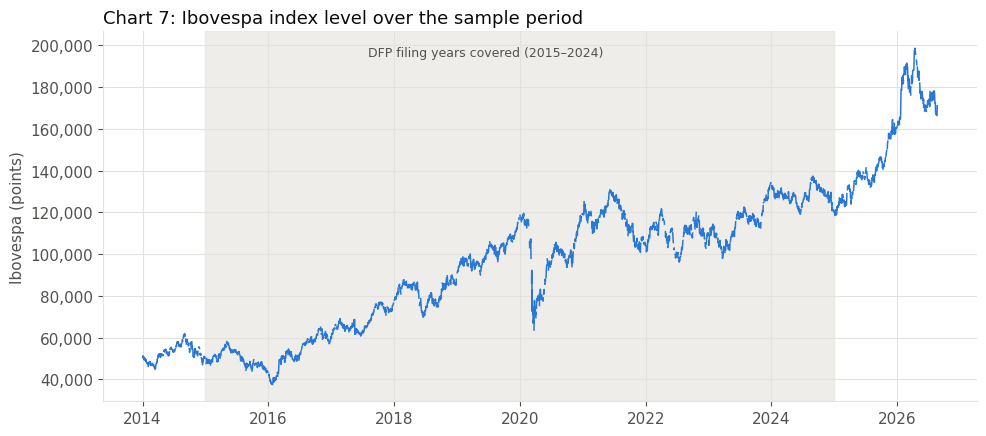

In [18]:
# Single series, single hue -- the DFP filing-year window (2015-2024) is
# shaded for context since that's what every note-similarity number above is
# anchored to.
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ibov["date"], ibov["ibov"], color=BLUE, linewidth=1.1)
ax.axvspan(pd.Timestamp("2015-01-01"), pd.Timestamp("2024-12-31"), color=GRID, alpha=0.6, zorder=0)
ax.text(pd.Timestamp("2019-06-15"), 0.96, "DFP filing years covered (2015–2024)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=9, color=TEXT_SECONDARY)
ax.set_ylabel("Ibovespa (points)")
ax.set_title("Chart 7: Ibovespa index level over the sample period", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
fig.tight_layout()
plt.show()

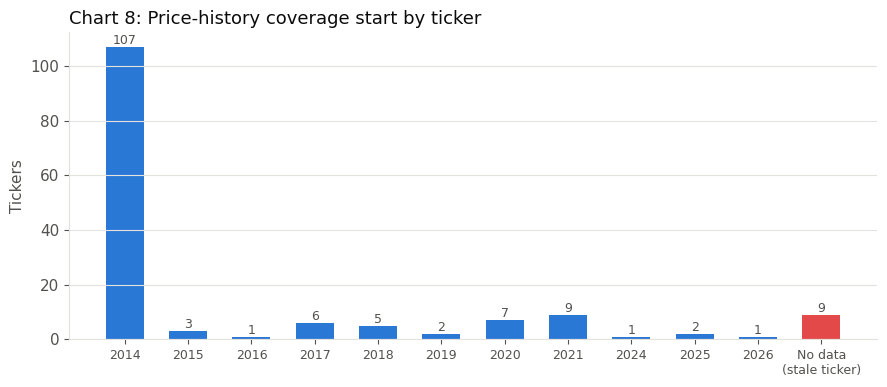

In [19]:
# Year a ticker's price history starts -- flags late listings/IPOs (shorter
# usable history for return calculations) and isolates the stale-ticker
# artifact as its own bucket rather than hiding it as a silent NaN.
first_valid_label = first_valid.dt.year.astype("Int64").astype(str)
first_valid_label = first_valid_label.where(first_valid.notna(), "No data\n(stale ticker)")
order = sorted(y for y in first_valid_label.unique() if y != "No data\n(stale ticker)")
if "No data\n(stale ticker)" in first_valid_label.values:
    order.append("No data\n(stale ticker)")
year_counts = first_valid_label.value_counts().reindex(order)
colors = [RED if label.startswith("No data") else BLUE for label in order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(year_counts.index, year_counts.values, color=colors, width=0.6)
ax.set_ylabel("Tickers")
ax.set_title("Chart 8: Price-history coverage start by ticker", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", labelsize=9)
for x, y in zip(year_counts.index, year_counts.values):
    ax.text(x, y + 1, str(y), ha="center", fontsize=9, color=TEXT_SECONDARY)
fig.tight_layout()
plt.show()

**Leitura:** a maioria dos tickers tem histórico de preço desde o início da janela do export (2014), bem antes de qualquer nota da amostra ter sido divulgada, então o cálculo de retorno não deve ficar truncado para a maior parte do universo. Um grupo menor começa mais tarde — IPOs/aberturas de capital genuínas durante o período da amostra, não um problema de dado.

**Cruzamento feito na Seção 7:** das 46 empresas históricas/deslistadas da Seção 5, só 30 resolvem para um ticker atual negociável (via cadastro vivo da B3) — as outras 16 fecharam capital, se fundiram por completo ou são massas falidas sem ticker algum para resolver, uma lacuna real, não um problema de qualidade de dado.

## 7. Primeiro olhar sobre H1: mudança textual prevê retorno anormal?

Com a similaridade da nota (Seções 2-5) e o dado de mercado (Seção 6) em mãos, a pergunta natural é a própria pergunta de pesquisa da dissertação, ainda que só como checagem em escala de POC: a mudança textual ano a ano na nota de dívida se associa ao retorno anormal subsequente da ação?

**O que calculo aqui, deliberadamente simples:**
- **Data do evento** — a data real de divulgação da DFP na CVM (não o fechamento do exercício) para o ano corrente de cada par de similaridade. Vem do índice bruto de arquivamentos da CVM (`DT_RECEB`) e está em [`data/interim/dfp_filing_dates.csv`](../data/interim/dfp_filing_dates.csv) (`src/acquisition/build_filing_dates.py`).
- **Retorno anormal** — o retorno *buy-and-hold* da ação nos ~252 pregões após a data do evento, menos o retorno *buy-and-hold* do Ibovespa na mesma janela. É um retorno ajustado ao mercado, não a um modelo de mercado — sem beta, sem controles de tamanho/valor/momento (`src/analysis/compute_abnormal_returns.py`). Isso precisa dos fundamentos que ainda faltam para entrar na regressão de verdade da dissertação.
- **Escopo** — o universo completo de 66 empresas atuais (Seção 2) mais as históricas/deslistadas (Seção 5), restrito aos pares com ticker resolvível e janela completa de 12 meses à frente. Só 30 das 46 empresas históricas resolvem para um ticker negociável.

In [20]:
ar = pd.read_csv(POC / "abnormal_returns_poc.csv")
ar_reliable = ar[(ar["diagnostic_prev"] == "font_heading") & (ar["diagnostic_curr"] == "font_heading")]

print(f"{len(ar)} pairs with both a similarity score and a computable 12-month abnormal return")
print(f"  current 66 companies:       {(ar['poc_group'] == 'current_66').sum()}")
print(f"  historical stayed/dropped:  {(ar['poc_group'] != 'current_66').sum()}\n")

for label, df in [("All computable pairs", ar), ("Reliable extraction only (font_heading/font_heading)", ar_reliable)]:
    pearson = df["cosine_similarity"].corr(df["abnormal_return"], method="pearson")
    spearman = df["cosine_similarity"].corr(df["abnormal_return"], method="spearman")
    print(f"{label}: n={len(df)}")
    print(f"  Pearson  r   (similarity, abnormal return) = {pearson:+.3f}")
    print(f"  Spearman rho (similarity, abnormal return) = {spearman:+.3f}")

704 pairs with both a similarity score and a computable 12-month abnormal return
  current 66 companies:       508
  historical stayed/dropped:  196

All computable pairs: n=704
  Pearson  r   (similarity, abnormal return) = -0.017
  Spearman rho (similarity, abnormal return) = +0.019
Reliable extraction only (font_heading/font_heading): n=450
  Pearson  r   (similarity, abnormal return) = -0.067
  Spearman rho (similarity, abnormal return) = -0.016


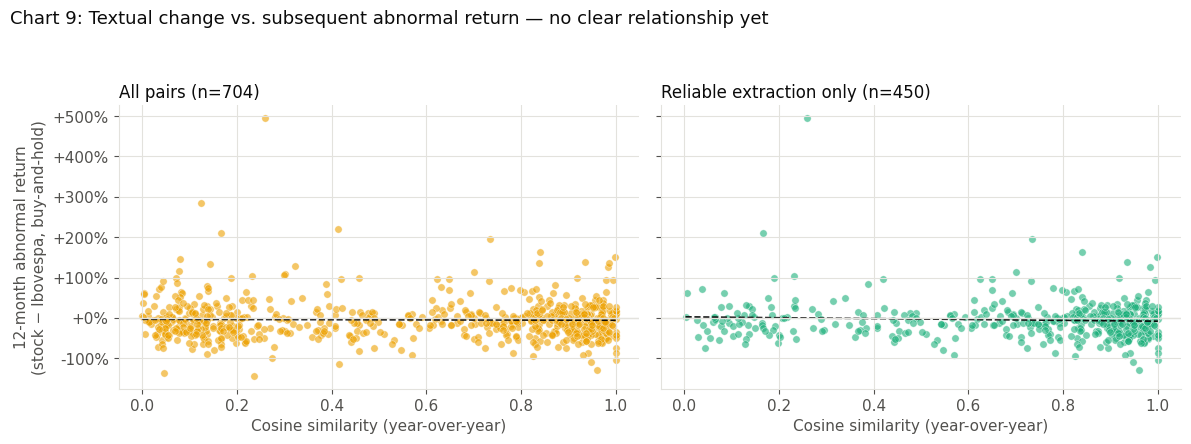

In [21]:
import numpy as np

# Same small-multiples pattern as Chart 4 (all pairs vs. reliable-only),
# now for the actual H1 relationship. A fitted trend line is shown for
# reference, not because n is anywhere near large enough to trust its slope.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, sharex=True)

for ax, (label, df, color) in zip(axes, [
    (f"All pairs (n={len(ar)})", ar, YELLOW),
    (f"Reliable extraction only (n={len(ar_reliable)})", ar_reliable, AQUA),
]):
    ax.scatter(df["cosine_similarity"], df["abnormal_return"], color=color, alpha=0.6, s=28, edgecolor="white", linewidth=0.4)
    z = np.polyfit(df["cosine_similarity"], df["abnormal_return"], 1)
    xs = np.array([df["cosine_similarity"].min(), df["cosine_similarity"].max()])
    ax.plot(xs, z[0] * xs + z[1], color=TEXT_PRIMARY, linewidth=1.2, linestyle="--")
    ax.axhline(0, color=GRID, linewidth=1)
    ax.set_title(label, loc="left", fontsize=12, color=TEXT_PRIMARY)
    ax.set_xlabel("Cosine similarity (year-over-year)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0%}"))

axes[0].set_ylabel("12-month abnormal return\n(stock − Ibovespa, buy-and-hold)")
fig.suptitle("Chart 9: Textual change vs. subsequent abnormal return — no clear relationship yet", x=0.01, ha="left", fontsize=13, color=TEXT_PRIMARY)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Leitura, sem rodeios:** ainda não há relação relevante — as correlações continuam fracas (|r| ≤ 0,07) nos dois sentidos, mesmo com mais pares disponíveis agora (n=704) e um conjunto confiável bem maior (n=450, contra 259 antes da rodada 5). Não é um resultado negativo para H1a, é o não-resultado esperado nesta etapa, por razões concretas:

1. **Sem controles.** O efeito de "Lazy Prices" de Cohen, Malloy e Nguyen aparece depois de controlar por tamanho, book-to-market e outras características — um retorno bruto ajustado ao mercado sobre algumas centenas de observações é exatamente o cenário em que esse efeito seria engolido por ruído.
2. **Ajustado ao mercado, não a um modelo de mercado.** Subtrair o Ibovespa não neutraliza o beta real da ação — uma ação de beta alto parece "anormal" em qualquer mercado de alta ou baixa forte, independentemente da sua nota. Várias janelas de evento caem perto de 2020 (COVID) ou outros choques macro.
3. **Extração bem mais confiável agora, mas ainda não universal.** Depois da rodada 6, cerca de 70% do corpus anual recebe a extração precisa `font_heading` (contra ~44% na rodada 4) — progresso real, mas o subconjunto confiável ainda não é o universo inteiro.

**O que esta seção estabelece:** o pipeline inteiro — similaridade da nota → data do evento → retorno futuro → retorno anormal ajustado ao mercado — roda de ponta a ponta sem erros, sobre dado real, no corpus completo já adquirido, agora com extração bem mais confiável por trás. É o correto a comprovar nesta etapa; o teste de verdade de H1/H1a precisa de controles reais e um retorno de modelo de mercado ou de fatores, não deste checkpoint.

## 8. Piloto trimestral (ITR): a mudança trimestral capturaria deterioração mais cedo?

Ideia motivadora: uma comparação só anual pode deixar até ~12 meses entre a deterioração real de uma empresa e o momento em que isso aparece como mudança textual ano a ano — potencialmente tarde demais para servir de sinal antecipado. Os arquivamentos trimestrais da CVM (ITR) trazem o mesmo tipo de nota explicativa, na cadência Q1/Q2/Q3 (o Q4 já é coberto pela DFP anual).

**Escopo:** o universo completo de 112 empresas (66 atuais + 46 históricas), a mesma cobertura anual da Seção 2, propagando as correções das rodadas 5 e 6 pela primeira vez nos dados trimestrais.

In [22]:
ITR_POC = DATA / "poc"
itr_sections = pd.DataFrame(
    json.loads(p.read_text(encoding="utf-8")) for p in sorted((ITR_POC / "itr_sections").glob("*.json"))
)
itr_sections["chars"] = itr_sections["text"].str.len()

itr_diag_counts = itr_sections["diagnostic"].value_counts().reindex(["font_heading", "regex_only", "not_found"])
for diag, n in itr_diag_counts.items():
    print(f"{DIAG_LABELS[diag]:22s} {n:3d}/{len(itr_sections)}  ({n/len(itr_sections):.0%})")

print(f"Para referencia, a base anual sobre o mesmo universo completo (Secao 2): 69.7% font_heading.")

Precisely bounded      1808/2915  (62%)
Imprecise fallback     876/2915  (30%)
Not found              231/2915  (8%)
Para referencia, a base anual sobre o mesmo universo completo (Secao 2): 69.7% font_heading.


In [23]:
itr_results = pd.read_csv(ITR_POC / "itr_similarity_results.csv")
itr_reliable = itr_results[(itr_results["diagnostic_prev"] == "font_heading") & (itr_results["diagnostic_curr"] == "font_heading")]

print("All quarter-over-quarter pairs:  n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(itr_results), itr_results["cosine_similarity"].mean(), itr_results["cosine_similarity"].median()))
print("Both quarters reliable:          n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(itr_reliable), itr_reliable["cosine_similarity"].mean(), itr_reliable["cosine_similarity"].median()))

itr_deg = itr_reliable[(itr_reliable["cosine_similarity"] >= 0.999) | (itr_reliable["cosine_similarity"] <= 0.001)]
print(f"\nDegenerate scores (>=0.999 or <=0.001) among reliable pairs: {len(itr_deg)}/{len(itr_reliable)} ({len(itr_deg)/len(itr_reliable):.0%})")

All quarter-over-quarter pairs:  n=2572  mean=0.64  median=0.85
Both quarters reliable:          n=1496  mean=0.80  median=0.94

Degenerate scores (>=0.999 or <=0.001) among reliable pairs: 115/1496 (8%)


**Um modo de falha novo, diferente de qualquer coisa nos dados anuais.** Boa parte dos pares degenerados vem de uma única empresa, MRV, presa numa extração idêntica de 119 caracteres ao longo de onze pares trimestrais seguidos — não é o artefato de "parágrafo de política contábil" já visto nos dados anuais (Yduqs, Seção 4), mas uma entrada de glossário/definição que aparentemente é estilizada como título nos arquivamentos trimestrais da MRV.

In [24]:
print("### Extraction artifact (new failure mode): MRV, 119-char glossary entry, 11 straight quarter-pairs at 1.0000 ###\n")
d = json.loads((ITR_POC / "itr_sections" / "020915_2015Q1.json").read_text(encoding="utf-8"))
print(f"Heading found: {d['heading']!r}\n")
print(d["text"])
print("\n^ 'SBPE -- Sistema Brasileiro de Poupanca e Emprestimo' is a glossary entry defining a financing-source")
print("  acronym, not the real debt note. Same 119-char text recurs identically across 11 consecutive quarters --")
print("  cosine similarity 1.0000 each time, a false 'no change' signal.")

### Extraction artifact (new failure mode): MRV, 119-char glossary entry, 11 straight quarter-pairs at 1.0000 ###

Heading found: 'SBPE – Sistema Brasileiro de Poupança e Empréstimo – Financiamento bancário que tem como fonte os'

SBPE – Sistema Brasileiro de Poupança e Empréstimo – Financiamento bancário que tem como fonte os
recursos da poupança.

^ 'SBPE -- Sistema Brasileiro de Poupanca e Emprestimo' is a glossary entry defining a financing-source
  acronym, not the real debt note. Same 119-char text recurs identically across 11 consecutive quarters --
  cosine similarity 1.0000 each time, a false 'no change' signal.


In [25]:
print("### Genuine signal, same 'boilerplate rolled forward' pattern as annual WEG (Chart 4/section 4): WEG 2023Q1 -> 2023Q2 ###\n")
d1 = json.loads((ITR_POC / "itr_sections" / "005410_2023Q1.json").read_text(encoding="utf-8"))
d2 = json.loads((ITR_POC / "itr_sections" / "005410_2023Q2.json").read_text(encoding="utf-8"))
row = itr_results[(itr_results["cd_cvm"] == 5410) & (itr_results["quarter_prev"] == "2023Q1") & (itr_results["quarter_curr"] == "2023Q2")].iloc[0]
print(f"WEG: 2023Q1 ({len(d1['text'])} chars) -> 2023Q2 ({len(d2['text'])} chars)")
print(f"cosine similarity = {row['cosine_similarity']:.4f}\n")
diff = list(difflib.unified_diff(d1["text"].splitlines(), d2["text"].splitlines(), lineterm="", n=0))
for line in diff[2:20]:
    print(line)
print("\n^ Same note structure carried forward quarter to quarter, only the reference date and balance figures")
print("  change -- exactly the pattern the annual pipeline validated, now confirmed at quarterly frequency too.")

### Genuine signal, same 'boilerplate rolled forward' pattern as annual WEG (Chart 4/section 4): WEG 2023Q1 -> 2023Q2 ###

WEG: 2023Q1 (2283 chars) -> 2023Q2 (2289 chars)
cosine similarity = 0.9987

@@ -3 +3 @@
-Encargos Anuais em 31/03/23
+Encargos Anuais em 30/06/23
@@ -6 +6 @@
-9.775
+8.372
@@ -11 +11 @@
-1.983
+2.047
@@ -15 +15 @@
-438
+414
@@ -20 +20 @@
-7.354
+5.911
@@ -23 +23 @@
-31.142
+41.995

^ Same note structure carried forward quarter to quarter, only the reference date and balance figures
  change -- exactly the pattern the annual pipeline validated, now confirmed at quarterly frequency too.


**Leitura:** a ideia central se transfere para a frequência trimestral — onde a extração é confiável, a similaridade de cosseno trimestral produz o mesmo tipo de sinal interpretável que o pipeline anual (ver o exemplo da WEG acima), e a taxa de extração confiável (62,0% no universo completo, depois das rodadas 5-6) está na mesma faixa da anual. Mas a confiabilidade em base anual não se transfere automaticamente para a trimestral — o artefato de glossário da MRV é um modo de falha genuinamente novo. Duas coisas ainda faltam antes disso deixar de ser um piloto:

1. **Endurecimento específico da base trimestral** — no mínimo, uma checagem contra entradas de glossário/definição e uma checagem de estabilidade mínima ao longo do histórico de cada empresa.
2. **O teste de "captura mais cedo" ainda não foi feito.** Esta seção só valida que a extração trimestral é viável — ainda não compara *quando* a mudança aparece. Isso precisa de casos de dificuldade financeira conhecidos (as empresas históricas/deslistadas da Seção 5 são os candidatos naturais) e checar se a queda de similaridade trimestral antecede a queda anual correspondente.

## Conclusão

**Sigo em frente — a confiabilidade de extração agora é maioria consolidada, não mais uma moeda no ar.** Entre as rodadas 4 e 6, a taxa de extração confiável no universo atual de 66 empresas foi de 44% para 71,6% (69,7% incluindo as históricas), com seis correções pontuais, cada uma rastreada a uma falha real inspecionada diretamente no PDF, não adivinhada. Duas ideias adicionais (detecção de sumário, referências cruzadas) foram testadas e descartadas por evidência, não por suposição. A distribuição de similaridade do grupo confiável se manteve sensata o tempo todo, e a taxa de pares degenerados caiu para 3,6% mesmo com quase o dobro de pares no conjunto.

**A checagem de viés de sobrevivência (Seção 5), refeita com dados bem mais confiáveis, confirma o quadro da rodada 4 em vez de mudá-lo.** Com o número de pares confiáveis subindo de 316 para 527, a comparação continua direcionalmente consistente e continua sem significância convencional (p=0,359 nos pares brutos, p=0,155 no corte por tamanho consistente). Essa é uma checagem negativa genuinamente útil: se o resultado nulo da rodada 4 fosse artefato de extração ruidosa no lado histórico, mais confiabilidade deveria ter empurrado o p-valor para significância. Não empurrou muito em nenhuma direção — minha leitura honesta continua "direcionalmente consistente, ainda não um achado significativo".

**Os dados de mercado (Seção 6) e o teste de H1 (Seção 7), refeitos com os dados endurecidos, continuam sem sinal.** 704 pares têm agora similaridade e retorno computáveis (450 deles confiáveis) — as correlações continuam triviais (|r| ≤ 0,07). Mesma conclusão de sempre: isso prova que o pipeline roda de ponta a ponta, não que H1/H1a se sustenta ou falha.

**O piloto trimestral (Seção 8) já recebeu as correções das rodadas 5-6 e está em 62,0% de confiabilidade no universo completo.**

O que ainda falta, em ordem de prioridade:
1. Extração agora é maioria confiável, mas não universal — a cauda residual é cada vez mais idiossincrática por empresa; mais ganhos provavelmente exigem ajustes específicos por empresa, com retorno decrescente por esforço.
2. O teste de H1/H1a de verdade precisa de controles reais (tamanho, alavancagem, book-to-market) e um retorno de modelo de mercado ou de fatores, não deste checkpoint — isso já está feito na dissertação principal (ver `docs/latex/main.tex`).
3. A pergunta de "captura mais cedo" da Seção 8 (mudança trimestral antecede a anual em casos de dificuldade conhecidos?) segue sem testar.
4. Só 30 das 46 empresas históricas têm ticker atual resolvível para dado de preço — uma decisão explícita de excluir vs. usar proxy ainda está pendente.